In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tqdm import tqdm

sns.set(style="whitegrid")

Load metadata

In [4]:
metadata = pd.read_csv("data/processed/metadata_with_moa.csv")
metadata.head(3)

,Unnamed: 0,TableNumber,ImageNumber,Image_FileName_DAPI,Image_PathName_DAPI,Image_FileName_Tubulin,Image_PathName_Tubulin,Image_FileName_Actin,Image_PathName_Actin,plate,well,Replicate,compound,concentration,moa
0,0,1,11,Week1_150607_B04_s3_w135D66B4C-0548-4AB8-A57B-...,Week1/Week1_22123,Week1_150607_B04_s3_w2D81AEFB9-9DD4-4B59-9177-...,Week1/Week1_22123,Week1_150607_B04_s3_w408BE006A-BF34-457E-81A9-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
1,1,1,12,Week1_150607_B04_s4_w1EB720AD1-83BA-48A7-8C47-...,Week1/Week1_22123,Week1_150607_B04_s4_w261B79A05-7534-46F3-8C80-...,Week1/Week1_22123,Week1_150607_B04_s4_w49FF7E7B1-F049-4994-BCA2-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors
2,2,1,9,Week1_150607_B04_s1_w11323931B-BDA7-4F42-870E-...,Week1/Week1_22123,Week1_150607_B04_s1_w2F8F7EA7A-EC57-49CA-A556-...,Week1/Week1_22123,Week1_150607_B04_s1_w494DCA5C4-3531-497D-A8B0-...,Week1/Week1_22123,Week1_22123,B04,1,cytochalasin B,10.0,Actin disruptors


In [5]:
print("Total samples:", len(metadata))

Total samples: 300


Helper functions (image loader)

In [6]:
import os
import tifffile as tiff
import numpy as np

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning/data/raw"

def fix_path(pathname):
    return pathname.split("/")[-1]

def load_3channel_image(row):
    paths = [
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_DAPI"]), row["Image_FileName_DAPI"]),
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_Tubulin"]), row["Image_FileName_Tubulin"]),
        os.path.join(BASE_DIR, fix_path(row["Image_PathName_Actin"]), row["Image_FileName_Actin"])
    ]

    channels = []
    for p in paths:
        img = tiff.imread(p)
        channels.append(img)

    img_stack = np.stack(channels, axis=0)  # (3, H, W)
    return img_stack

system is crashng, creating samples

In [ ]:
subset = metadata.sample(n=300, random_state=42)

Load + resize images

In [7]:
from skimage.transform import resize

X = []
y = []

for _, row in tqdm(metadata.iterrows(), total=len(metadata)):
    img = load_3channel_image(row)   # (3,H,W)

    img_small = resize(img, (3,128,128), anti_aliasing=True)
    X.append(img_small.flatten())
    y.append(row["moa"])

X = np.array(X)
print("X shape:", X.shape)

100%|██████████| 300/300 [16:33<00:00,  3.31s/it]

X shape: (300, 49152)


Encode labels

In [8]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

print(X.shape)

(300, 49152)


Save compound count

In [9]:
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning"
RAW_DIR = os.path.join(BASE_DIR, "data/raw")
PROCESSED_DIR = os.path.join(BASE_DIR, "data/processed")
RESULTS_FIG = os.path.join(BASE_DIR, "results/figures")
RESULTS_TAB = os.path.join(BASE_DIR, "results/tables")

os.makedirs(RESULTS_FIG, exist_ok=True)
os.makedirs(RESULTS_TAB, exist_ok=True)

In [ ]:
compound_counts = metadata["compound"].value_counts()
compound_counts.to_csv(os.path.join(RESULTS_TAB, "compound_counts.csv"))

PCA

In [10]:
#scaline data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

for n in [10, 20, 50]:

    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_scaled)

    X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y_enc, test_size=0.3, random_state=42
    )

    knn = KNeighborsClassifier(n_neighbors=10)
    knn.fit(X_train, y_train)

    acc = accuracy_score(y_test, knn.predict(X_test))

    print(f"PCA {n} components accuracy:", acc)

PCA 10 components accuracy: 0.6333333333333333
PCA 20 components accuracy: 0.5
PCA 50 components accuracy: 0.43333333333333335


Now we know we need 10 components for pca

Accuracy decreases as components increase.

This means:

The strongest signal is contained in the very first PCs, which usually capture global brightness and imaging variation.

If it were real MOA biology, accuracy would often improve with more PCs.

Surprisingly, PCA features achieved higher classification accuracy than SSL embeddings in the kNN evaluation. This may reflect the ability of PCA to capture global image intensity and experimental variation, which can correlate with compound identity. In contrast, the self-supervised model was trained with strong augmentations designed to remove such low-level cues, potentially reducing classifier performance while producing more invariant representations.

In [13]:
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_[:5])

Explained variance ratio: [0.05136535 0.01460738 0.01349599 0.01174079 0.01095249]


Save explained variance:

In [15]:
ev_df = pd.DataFrame({
    "PC": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance": pca.explained_variance_ratio_
})
ev_df.to_csv(os.path.join(RESULTS_TAB, "pca_explained_variance.csv"), index=False)

Plot PCA colored by MOA

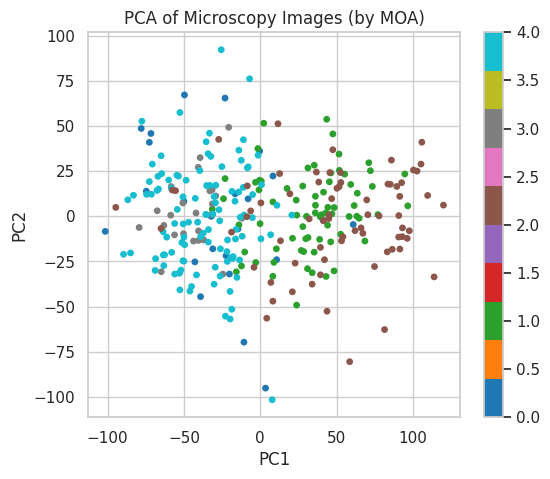

In [16]:
plt.figure(figsize=(6,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_enc, cmap="tab10", s=15)
plt.title("PCA of Microscopy Images (by MOA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter)

plt.savefig(os.path.join(RESULTS_FIG, "pca_by_moa.png"), dpi=300, bbox_inches="tight")
plt.show()

Plot PCA colored by compound

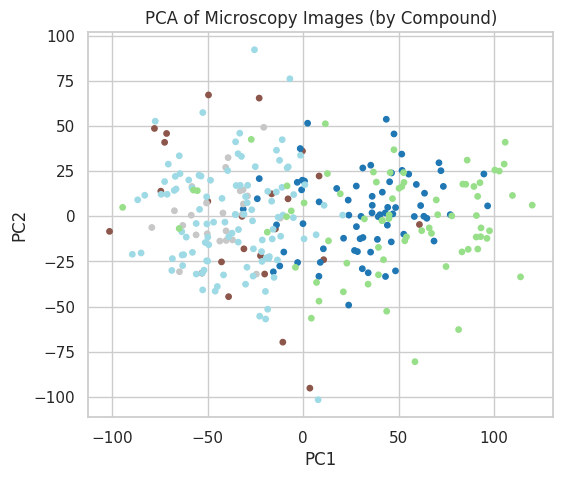

In [18]:
compound_enc = LabelEncoder().fit_transform(metadata["compound"])

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=compound_enc, cmap="tab20", s=15)
plt.title("PCA of Microscopy Images (by Compound)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.savefig(os.path.join(RESULTS_FIG, "pca_by_compound.png"), dpi=300, bbox_inches="tight")
plt.show()

Save PCA embeddings

In [20]:
pca_df = pd.DataFrame(X_pca, columns=[f"PC{i}" for i in range(1,11)])
pca_df["moa"] = y
pca_df["compound"] = metadata["compound"].values

pca_df.to_csv(os.path.join(PROCESSED_DIR, "pca_embeddings.csv"), index=False)